This script explores probability of dying and at real implementaion of the [Gompertz–Makeham law of mortality](https://en.wikipedia.org/wiki/Gompertz%E2%80%93Makeham_law_of_mortality), based on data from [life tables](https://en.wikipedia.org/wiki/Life_table).

Data sources: [Japan](https://www.ipss.go.jp/p-toukei/JMD/00/index-en.html), [Tokyo](https://www.ipss.go.jp/p-toukei/JMD/13/index-en.html), [Kyoto](https://www.ipss.go.jp/p-toukei/JMD/26/index-en.html) → "Life Tables"<br>
wiki > [List of Japanese prefectures by life expectancy](https://en.wikipedia.org/wiki/List_of_Japanese_prefectures_by_life_expectancy) <i>[(alternative)](https://en.wikipedia.org/wiki/User:Lady3mlnm/List_of_Japanese_prefectures_by_life_expectancy_(alternative))</i> / [Продолжительность жизни в префектурах Японии](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_префектурах_Японии)<br />
[Demographics of Tokyo](https://en.wikipedia.org/wiki/Demographics_of_Tokyo#Percentage_surviving)<br>
[selection of colors](http://mal-bioit.ru/survey-web-colors)<br />
see also: [Nippon.com](https://www.nippon.com/en/search.html?s=life%20expectancy)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import re
from collections import namedtuple

In [3]:
# pd.options.display.max_rows=100

In [4]:
LANG = 'en'  # language of the chart (is setting doesn't have influence on tables)
YEAR = 2020
WRITE_TABLE = False
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

NMB_PREF1 = 13        # number for Tokyo
NMB_PREF2 = 26        # number for Kyoto
NMB_PREF3 = 25        # number for Shiga

In [5]:
# This block of code extracts name of region from CSV-file with data.
# This name is used only to name correctly file with resuls of the script work

pattern_region_general = re.compile(r'(?<=^[\d.]{3}).*(?=(.ken|.to|.fu), Life tables)')  # what is in the most cases, like '47.Okinawa.ken'
pattern_region_1       = re.compile(r'(?<=^[\d.]{3}).*(?=, Life tables)')  # case of '01.Hokkaido' in the file Jp_01.csv
pattern_region_0       = re.compile(r'(?<=^).*(?=, Life tables)')  # case of 'Japan' in the file Jp_01.csv

def extract_name_of_region_from_file(region_nmb):
    with open(f"data-Life_tables/JpLT_{region_nmb:02}-total.csv", 'r') as fh:
        title_line = fh.readline()
        if region_nmb >= 2:
            fragment_name_found = re.search(pattern_region_general, title_line)
        elif region_nmb == 1:
            fragment_name_found = re.search(pattern_region_1, title_line)
        elif region_nmb == 0:
            fragment_name_found = re.search(pattern_region_0, title_line)
        else:
            raise ValueError(f"Not expected region number: {region_nmb}")
        name = fragment_name_found.group() if fragment_name_found else 'region name is not found'
    return name


name_pref1 = extract_name_of_region_from_file(NMB_PREF1)
print(f"Region #{NMB_PREF1} - {name_pref1}")

name_pref2 = extract_name_of_region_from_file(NMB_PREF2)
print(f"Region #{NMB_PREF2} - {name_pref2}")

name_pref3 = extract_name_of_region_from_file(NMB_PREF3)
print(f"Region #{NMB_PREF3} - {name_pref3}")

Region #13 - Tokyo
Region #26 - Kyoto
Region #25 - Shiga


<br>

In [7]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'color', 'style', 'width', 'alpha'])

In [8]:
def read_single_csv_probability_for_given_age(nmb_region, age, suffix_for_columns=''):
    '''This function load data for percentage surviving for a single prefecture or a country as a whole'''
    df_m = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-males.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_m = df_m.loc[df_m['Age'] == age] \
               .drop(columns='Age') \
               .set_index('Year')
    df_m['qx'] = df_m['qx'] * 100
    # df_m = df_m.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_t = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-total.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_t = df_t.loc[df_t['Age'] == age] \
               .drop(columns='Age') \
               .set_index('Year')
    df_t['qx'] = df_t['qx'] * 100
    # df_t = df_t.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_f = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-females.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_f = df_f.loc[df_f['Age'] == age] \
               .drop(columns='Age') \
               .set_index('Year')
    df_f['qx'] = df_f['qx'] * 100
    # df_f = df_f.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('male', 'total', 'female')

    df['mΔf'] = df['male'] - df['female']     # No requirement for rounding since numbers are integers
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]

    return df

age_to_explore = '109'
df_to_explore = pd.concat([
        read_single_csv_probability_for_given_age(0, age=age_to_explore),
        read_single_csv_probability_for_given_age(NMB_PREF1, age=age_to_explore, suffix_for_columns='_pref1'),
        read_single_csv_probability_for_given_age(NMB_PREF2, age=age_to_explore, suffix_for_columns='_pref2'),
        read_single_csv_probability_for_given_age(NMB_PREF3, age=age_to_explore, suffix_for_columns='_pref3')], axis='columns')

df_to_explore.loc[2000:]

,male,total,female,mΔf,ratio_mf,male_pref1,total_pref1,female_pref1,mΔf_pref1,ratio_mf_pref1,male_pref2,total_pref2,female_pref2,mΔf_pref2,ratio_mf_pref2,male_pref3,total_pref3,female_pref3,mΔf_pref3,ratio_mf_pref3
,,,,,,,,,,,,,,,,,,,,
2000,50.580,49.523,49.330,1.250,1.03,49.649,47.807,47.701,1.948,1.04,49.446,47.634,47.382,2.064,1.04,51.182,51.036,50.946,0.236,1.00
2001,50.673,49.421,49.162,1.511,1.03,50.036,48.589,48.378,1.658,1.03,50.431,48.839,48.649,1.782,1.04,50.018,50.898,51.348,-1.330,0.97
2002,50.084,48.833,48.600,1.484,1.03,50.053,47.517,47.126,2.927,1.06,50.785,47.240,46.751,4.034,1.09,50.807,50.395,50.159,0.648,1.01
2003,50.753,49.086,48.854,1.899,1.04,49.496,47.309,46.954,2.542,1.05,50.811,47.789,47.333,3.478,1.07,52.294,51.403,50.616,1.678,1.03
2004,50.174,48.846,48.634,1.540,1.03,48.572,47.595,47.490,1.082,1.02,50.928,48.633,48.380,2.548,1.05,51.864,51.447,51.170,0.694,1.01
2005,51.549,49.754,49.565,1.984,1.04,51.238,49.252,49.007,2.231,1.05,52.019,49.800,49.522,2.497,1.05,54.066,52.037,50.609,3.457,1.07
2006,50.744,49.353,49.214,1.530,1.03,50.842,48.322,48.127,2.715,1.06,51.288,49.358,49.002,2.286,1.05,50.194,51.113,51.518,-1.324,0.97
2007,50.363,49.440,49.361,1.002,1.02,49.865,48.166,47.997,1.868,1.04,50.710,49.330,48.942,1.768,1.04,50.788,50.541,50.460,0.328,1.01
2008,51.322,49.916,49.808,1.514,1.03,50.515,48.575,48.454,2.061,1.04,51.127,49.246,48.913,2.214,1.05,50.788,50.682,50.656,0.132,1.00


<br>

In [10]:
def read_single_csv(nmb_region, year, suffix_for_columns=''):
    '''This function load data for percentage surviving for a single prefecture or a country as a whole'''
    df_m = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-males.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_m = df_m.loc[df_m['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_m['qx'] = df_m['qx'] * 100
    df_m = df_m.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_t = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-total.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_t = df_t.loc[df_t['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_t['qx'] = df_t['qx'] * 100
    df_t = df_t.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df_f = pd.read_csv(f"data-Life_tables/JpLT_{nmb_region:02}-females.csv", sep='\t', usecols=['Year', 'Age', 'qx'], skiprows=2)
    df_f = df_f.loc[df_f['Year'] == year] \
               .drop(columns='Year') \
               .set_index('Age')
    df_f['qx'] = df_f['qx'] * 100
    df_f = df_f.rename(index={'110+': '110'}).rename(index=lambda st: int(st))

    df = pd.concat([df_m, df_t, df_f], axis='columns')
    df.index.name = ''
    df.columns = ('male', 'total', 'female')

    df['mΔf'] = df['male'] - df['female']     # No requirement for rounding since numbers are integers
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]

    return df

df = pd.concat([
        read_single_csv(0, year=YEAR),
        read_single_csv(NMB_PREF1, year=YEAR, suffix_for_columns='_pref1'),
        read_single_csv(NMB_PREF2, year=YEAR, suffix_for_columns='_pref2'),
        read_single_csv(NMB_PREF3, year=YEAR, suffix_for_columns='_pref3')], axis='columns')

# drop values for 110, since this record doesn't have sense
df.drop(index=110, inplace=True)

df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109]]

,male,total,female,mΔf,ratio_mf,male_pref1,total_pref1,female_pref1,mΔf_pref1,ratio_mf_pref1,male_pref2,total_pref2,female_pref2,mΔf_pref2,ratio_mf_pref2,male_pref3,total_pref3,female_pref3,mΔf_pref3,ratio_mf_pref3
,,,,,,,,,,,,,,,,,,,,
0,0.187,0.180,0.174,0.013,1.07,0.129,0.137,0.146,-0.017,0.88,0.120,0.129,0.139,-0.019,0.86,0.150,0.183,0.218,-0.068,0.69
1,0.026,0.022,0.018,0.008,1.44,0.018,0.013,0.009,0.009,2.00,0.002,0.009,0.019,-0.017,0.11,0.023,0.032,0.044,-0.021,0.52
5,0.007,0.007,0.007,0.000,1.00,0.010,0.010,0.009,0.001,1.11,0.005,0.006,0.007,-0.002,0.71,0.006,0.006,0.007,-0.001,0.86
10,0.005,0.006,0.006,-0.001,0.83,0.004,0.006,0.008,-0.004,0.50,0.001,0.004,0.007,-0.006,0.14,0.004,0.004,0.005,-0.001,0.80
20,0.039,0.031,0.022,0.017,1.77,0.038,0.027,0.015,0.023,2.53,0.039,0.029,0.022,0.017,1.77,0.047,0.037,0.027,0.020,1.74
30,0.052,0.040,0.027,0.025,1.93,0.038,0.031,0.024,0.014,1.58,0.038,0.028,0.020,0.018,1.90,0.031,0.029,0.026,0.005,1.19
40,0.092,0.077,0.063,0.029,1.46,0.083,0.065,0.046,0.037,1.80,0.093,0.073,0.058,0.035,1.60,0.093,0.081,0.072,0.021,1.29
50,0.247,0.198,0.147,0.100,1.68,0.238,0.191,0.141,0.097,1.69,0.228,0.173,0.122,0.106,1.87,0.191,0.143,0.088,0.103,2.17
60,0.609,0.444,0.281,0.328,2.17,0.616,0.460,0.301,0.315,2.05,0.596,0.417,0.237,0.359,2.51,0.462,0.344,0.238,0.224,1.94


In [11]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109], ['male', 'male_pref1', 'male_pref2', 'male_pref3', 'female', 'female_pref1', 'female_pref2', 'female_pref3']]

,male,male_pref1,male_pref2,male_pref3,female,female_pref1,female_pref2,female_pref3
,,,,,,,,
0,0.187,0.129,0.120,0.150,0.174,0.146,0.139,0.218
1,0.026,0.018,0.002,0.023,0.018,0.009,0.019,0.044
5,0.007,0.010,0.005,0.006,0.007,0.009,0.007,0.007
10,0.005,0.004,0.001,0.004,0.006,0.008,0.007,0.005
20,0.039,0.038,0.039,0.047,0.022,0.015,0.022,0.027
30,0.052,0.038,0.038,0.031,0.027,0.024,0.020,0.026
40,0.092,0.083,0.093,0.093,0.063,0.046,0.058,0.072
50,0.247,0.238,0.228,0.191,0.147,0.141,0.122,0.088
60,0.609,0.616,0.596,0.462,0.281,0.301,0.237,0.238


<br>

In [13]:
# explore the the "plateau" manually, if we want
# df.loc[16:40]

In [14]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = pd.concat([
    df.loc[plateau_years, ['male', 'total', 'female']].mean(),
    df.loc[plateau_years, ['male_pref1', 'total_pref1', 'female_pref1']].mean().rename(index={'male_pref1':'male', 'total_pref1':'total', 'female_pref1':'female'}),
    df.loc[plateau_years, ['male_pref2', 'total_pref2', 'female_pref2']].mean().rename(index={'male_pref2':'male', 'total_pref2':'total', 'female_pref2':'female'}),
    df.loc[plateau_years, ['male_pref3', 'total_pref3', 'female_pref3']].mean().rename(index={'male_pref3':'male', 'total_pref3':'total', 'female_pref3':'female'})
], axis='columns').T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['Japan', name_pref1, name_pref2, name_pref3]
dfe.round(3)

,male,total,female,ratio_mf
Japan,0.050,0.038,0.026,1.98
Tokyo,0.038,0.031,0.023,1.65
Kyoto,0.047,0.033,0.019,2.47
Shiga,0.041,0.035,0.027,1.51


In [15]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_total'] = dfe['total'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,total,female,ratio_mf,le_ageless_male,le_ageless_total,le_ageless_female
Japan,0.050,0.038,0.026,1.98,1980,2604,3921
Tokyo,0.038,0.031,0.023,1.65,2597,3246,4291
Kyoto,0.047,0.033,0.019,2.47,2127,3021,5263
Shiga,0.041,0.035,0.027,1.51,2439,2873,3676


<br>

In [17]:
def create_table(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    prec = 3
    for age in [1] + list(range(5, 106, 5)) + [109]:
        ser = df.loc[age]
        st += '\n' + '|-\n' + \
            f'|style="padding-right:3ex;"| {age} ' + \
            f'||style="color:blue;padding-right:1ex;"| {transform_value(ser.loc['male'], prec=prec)} ' + \
            f'||style="padding-right:1ex;"| {transform_value(ser.loc['total'], prec=prec)} ' + \
            f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['female'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {transform_value(ser.loc['mΔf'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf']:0.2f} ' + \
            f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['male_pref1'], prec=prec)} ' + \
            f'||style="padding-right:1ex;"| {transform_value(ser.loc['total_pref1'], prec=prec)} ' + \
            f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['female_pref1'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {transform_value(ser.loc['mΔf_pref1'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_pref1']:0.2f} ' + \
            f'||style="color:blue;padding-right:1ex;border-left-width:2px;"| {transform_value(ser.loc['male_pref2'], prec=prec)} ' + \
            f'||style="padding-right:1ex;\"| {transform_value(ser.loc['total_pref2'], prec=prec)} ' + \
            f'||style="color:red;padding-right:1ex;"| {transform_value(ser.loc['female_pref2'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {transform_value(ser.loc['mΔf_pref2'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_pref2']:0.2f}'

    # fix microbugs that can happened due to nuances of calculations and rounding
    st = st.replace('color:darkgray;padding-right:3ex;"| -0.0 ', 'color:darkgray;padding-right:3ex;"| 0.0 ')
    
    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits

    st = table_header + st + '\n|}'
    return st
        

if WRITE_TABLE:
    table_code = create_table(df, file_header='Probability_of_dying_extended -en.txt', lang='en')
    with open(f"output/Table code for probability of dying extended -{YEAR} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

    # table_code = create_table(df, file_header='Probability_of_dying_extended -ru.txt', lang='ru')
    # with open('output/Table code for probability surviving extended -ru.txt', 'w', encoding="utf-8") as fh:
    #     fh.write(table_code)

<br>
<br>

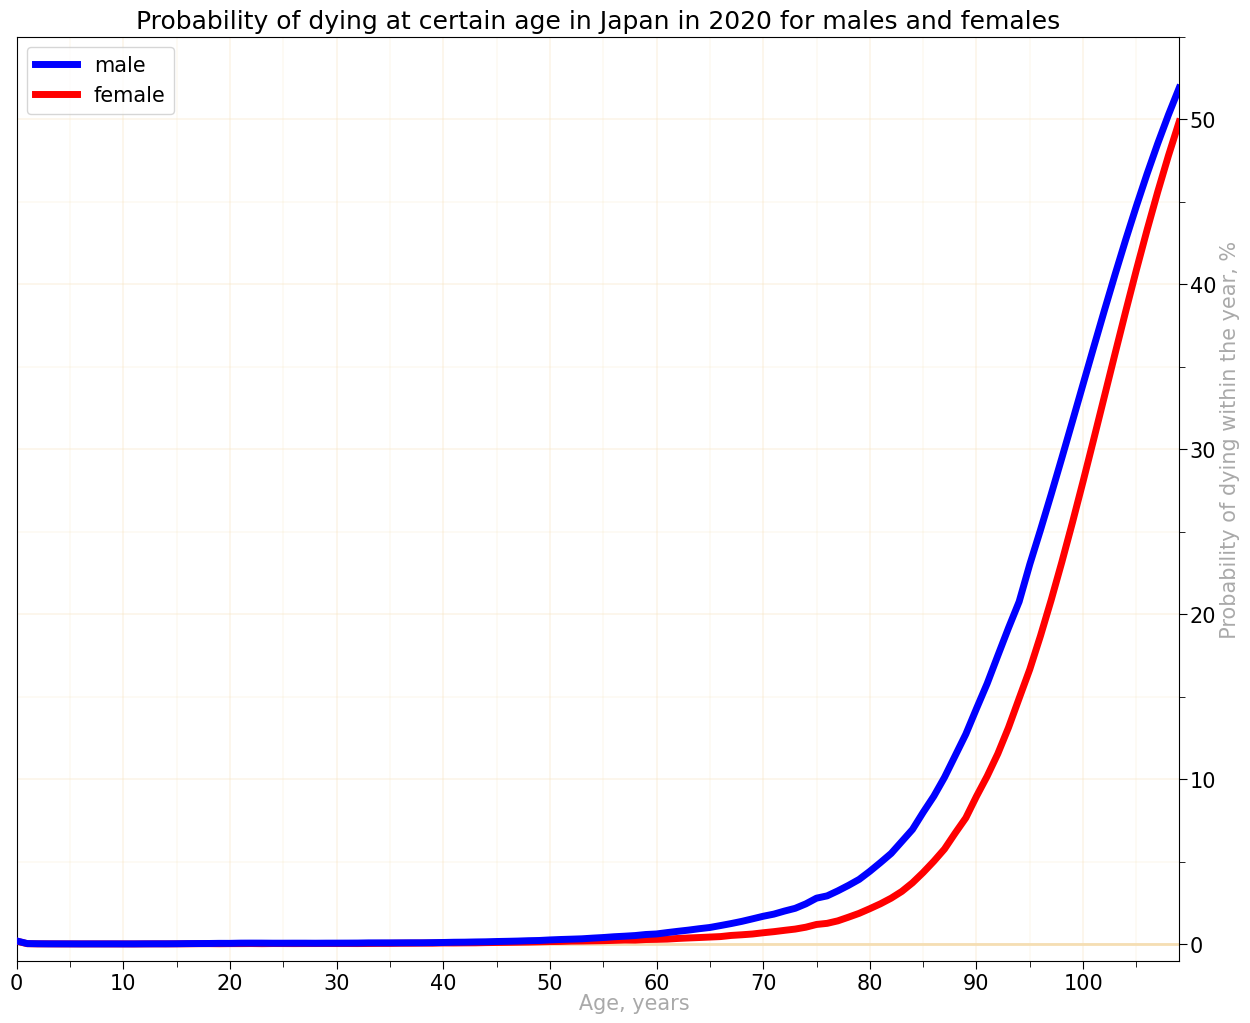

In [19]:
def create_chart(
        df, lang=LANG, dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)  # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)  # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5)  # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)  # Minor ticks are shorter
    plt.xticks(fontsize=15)  # font size for tick labels
    plt.yticks(fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 55
    plt.xlim(0, 109)
    plt.ylim(-1, 55)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("          Вероятность смерти в течение года, %" if lang=='ru' else
               "                  Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=3)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'female': DisplayedGroup(en_name="female",  ru_name="женщины", color='red',       style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", color='lightgrey', style='-', width=5, alpha=1),
    'male'  : DisplayedGroup(en_name="male",    ru_name="мужчины", color='blue',      style='-', width=5, alpha=1),
}

create_chart(df.T.loc[['male', 'female']],
             dd_display=dd_display, lang=LANG,
             title_en=f"Probability of dying at certain age in Japan in {YEAR} for males and females",  # , overall statistics for males and females
             title_ru=f"Вероятность смерти в определённом возрасте в Японии в {YEAR} для мужчин и женщин",
             file_name=f"Probability of Dying at Certain Age in Japan in {YEAR}")

Average mortality rate at the interval 21–30 years (incl.), %:   ♂: 0.051, ♀: 0.026
Average life expectancy, if the mortality rate was the same as at the plateau, years:   ♂: 1980, ♀: 3920


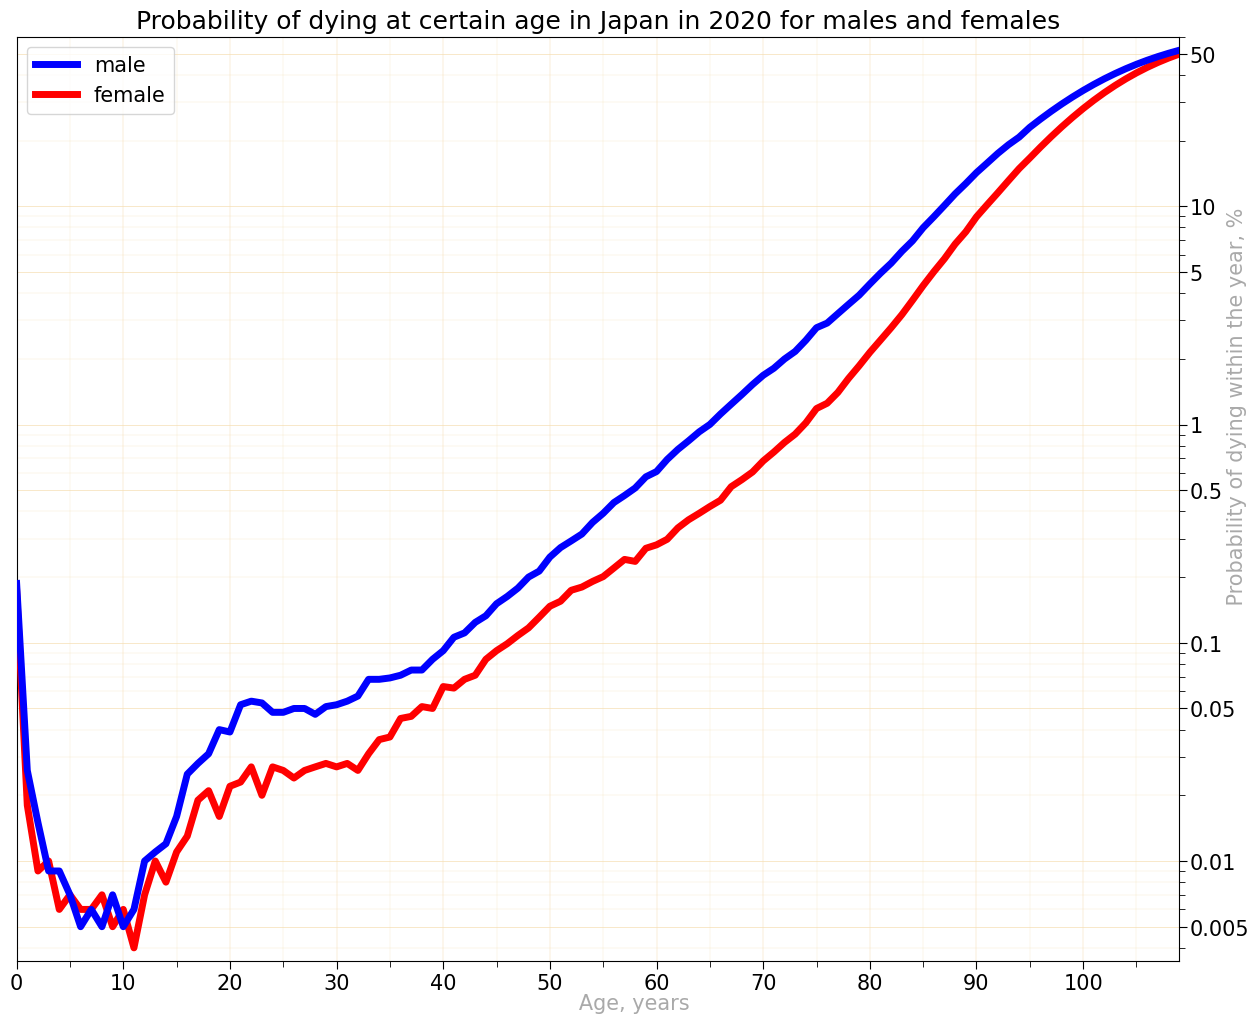

In [20]:
def create_chart_log(
        df, lang=LANG, dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика",
        plateau_years = slice(21, 30), show_plateau_lines=False,
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.0035, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # for y_milestone in [0.1, 1, 10]:
    #     plt.axhline(y=y_milestone, color='wheat', linewidth=0.5)

    plt.title(title_ru if lang=='ru' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("           Вероятность смерти в течение года, %" if lang=='ru' else
               "                            Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    # Calculate and show statistics about "plateau" (from 21 to 30 years, including endpoints)
    plateau_mortality_male   = df.loc['male', plateau_years].mean()
    plateau_mortality_female = df.loc['female', plateau_years].mean()
    print(f"Average mortality rate at the interval {plateau_years.start}–{plateau_years.stop} years (incl.), %:   ♂: {plateau_mortality_male:.3f}, ♀: {plateau_mortality_female:.3f}")
    le_average_plateau_male   = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_male)
    le_average_plateau_female = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_female)
    print(f"Average life expectancy, if the mortality rate was the same as at the plateau, years:   ♂: {round(le_average_plateau_male, -1)}, ♀: {round(le_average_plateau_female, -1)}")
    
    if show_plateau_lines:  # show plateaux visually 
        for y_plateau in [plateau_mortality_male, plateau_mortality_female]:
             plt.hlines(y_plateau, plateau_years.start-5, plateau_years.stop+5, color='lime', linewidth=2, alpha=0.5)
    
    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'female': DisplayedGroup(en_name="female",  ru_name="женщины", color='red',       style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", color='lightgrey', style='-', width=5, alpha=1),
    'male'  : DisplayedGroup(en_name="male",    ru_name="мужчины", color='blue',      style='-', width=5, alpha=1),
}

create_chart_log(df.T.loc[['male', 'female']],
             dd_display=dd_display, lang=LANG,
             title_en=f"Probability of dying at certain age in Japan in {YEAR} for males and females",  # , overall statistics for males and females
             title_ru=f"Вероятность смерти в определённом возрасте в Японии в {YEAR} для мужчин и женщин",
             file_name=f"Probability of Dying at Certain Age in Japan in {YEAR} -log")

<br>
<br>

In [22]:
# Functions that I tried to use for approximations of a perido 40-90 years,
# where Gompertz–Makeham law of mortality takes place, but the result turned out unsatisfactory.
## Gompertz function with permanent Makeham component:
# def gompertz_makeham(age, amplitude, coef, external_mortality):
#     return amplitude * np.exp(coef * age) + makeham_component  # makeham_component - permanent external mortality

## simple Gompertz function
# def gompertz(age, amplitude, coef):
#     return amplitude * np.exp(coef * age)

# segment of ages (including endpoints) where aproximation is searched
# range_start = 40
# range_end = 90

# Lines of code that have to be inserted into the chart creation function
# to laucn approximation.
## Approximate data for segment where Gompertz–Makeham law of mortality takes place
# x_originals = np.linspace(range_start, range_end, range_end-range_start+1)
# y_originals = df.loc[group, x_originals].values / 100

# for group in ['male', 'female']:
#     coefs, _ = curve_fit(gompertz_makeham, x_originals, y_originals, p0=[1e-6, 0.10, 0.0005], maxfev = 100_000)
#     y_approximated = gompertz_makeham(x_originals, *coefs) * 100
#     plt.plot(x_originals, y_approximated, color='orange', linewidth=10, alpha=0.5, zorder=101)

In [23]:
# play beep to denote completion of the program
import IPython.display as ipd
import numpy as np

# manually generated sound
t = 1  # time is seconds
beep = np.sin(2*np.pi*400*np.arange(10000*t)/10000)
ipd.Audio(beep, rate=10000, autoplay=True)